# Capstone Function 1
Detect likely contamination source in a two-dimensional area, such as a radiation field, where only proximity yeilds a non-zero reading.  The system uses Bayesian Optimization to tune detection parameters and reliably identify both strong and weak sources
| Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

## Notes
- Inputs are in range 0 to 1
- outputs very small - 0 if not close the source
- This is a maximisation task - negate outputs to use with standard python library skopt

# Data Analysis

shape of inputs: (14, 2)
shape of outputs: (14,)
     input_0   input_1    output
0   0.319404  0.762959  0.277350
1   0.574329  0.879898  0.277350
2   0.731024  0.733000  0.277350
3   0.840353  0.264732  0.277350
4   0.650114  0.681526 -3.605551
5   0.410437  0.147554  0.277350
6   0.312691  0.078723  0.277350
7   0.683418  0.861057  0.277350
8   0.082507  0.403488  0.277350
9   0.883890  0.582254  0.277350
10  0.448979  0.142857  0.277350
11  0.708964  0.494269  0.277350
12  0.986481  0.986619  0.277350
13  0.060194  0.333985  0.277350


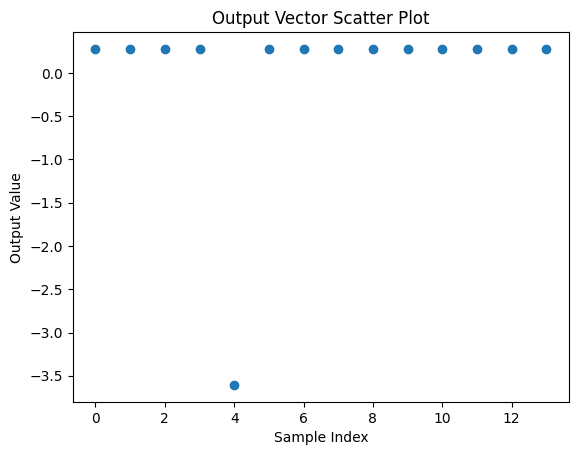

In [8]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# load the .npy file
inputs = np.load("../data/f1/updated_inputs - Week 4.npy")
outputs = np.load("../data/f1/updated_outputs - Week 4.npy")

# shift outputs to make them all positive
epsilon = 2 * abs(np.min(outputs))
outputs_shifted = outputs + epsilon

# log transform the shifted outputs
outputs_log = np.log10(outputs_shifted)


mean_output = np.mean(outputs_log)
std_output = np.std(outputs_log)
output_norm = (outputs_log - mean_output) / std_output


# summarize shape
print(f'shape of inputs: {inputs.shape}')
print(f'shape of outputs: {outputs.shape}')

# create a dataframe from inputs and outputs
data = pd.DataFrame(inputs, columns=[f'input_{i}' for i in range(inputs.shape[1])])
data['output'] = output_norm
print(data.tail(15))

# display the output vector as a scatter plot
plt.scatter(range(len(outputs)), output_norm)
plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('Output Vector Scatter Plot')
plt.show()

## Observations
- Outputs are very small numbers.  Engineering intuition tells me that noise may impact these results signficantly

# Gaussian Process with Upper Confidence Bound Acquisition Function
1. Using the code from Module 12, I get rubbish numbers, but Copilot generated code seems to yeild a better mean, but throws an error re: convergence

In [3]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# parameters from Module 12 - not yet celar on their meaning
rbf_lengthscale = 0.1
noise_assumption = 1e-10


# Load the dataset provided
X = np.load("data/initial_inputs.npy")
y = np.load("data/initial_outputs.npy")

# Define the kernel for Gaussian Process - this is generated by Copilot - do not yet understand this properly
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3))

# Using the kernel creation code from Module 12
#kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
# code from module 12
# gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

gp.fit(X, y)


# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 100
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound (UCB) acquisition function
kappa = 2.0  # Exploration-exploitation trade-off parameter
ucb = mean + kappa * std

# Select the next input sample as the point with the highest UCB
next_index = np.argmax(ucb)
next_sample = X_grid[next_index]

print("Next input sample based on UCB:", next_sample)
print("Predicted mean:", mean[next_index])


Next input sample based on UCB: [0.70707071 0.        ]
Predicted mean: -2.405920382948486e-06


/Users/brucediesel/.pyenv/versions/pyDev/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Gaussian Process with PI Acquisition Function
Using the xi value of 0.01

In [32]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Probability of Improvement (PI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
pi = norm.cdf(z)

# Select the next input sample as the point with the highest PI
next_index = np.argmax(pi)
next_sample = X_grid[next_index]

print("Next input sample based on PI:", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])


Next input sample based on PI: [0.04081633 0.40816327]
Predicted mean: -0.00034838978526955647
Predicted std deviation: 0.0010940662603356574


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Gaussian Process with EI Acquisition Function

In [35]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Expected Improvement (EI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.005  # Small margin for improvement
z = (mean - best_y - xi) / std
ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

# Select the next input sample as the point with the highest EI
next_index = np.argmax(ei)
next_sample = X_grid[next_index]

print("Next input sample based on Expected Improvement (EI):", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])


Next input sample based on Expected Improvement (EI): [0.44897959 0.14285714]
Predicted mean: -0.0003406260603901083
Predicted std deviation: 0.001093012059247324


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Visualisation

/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


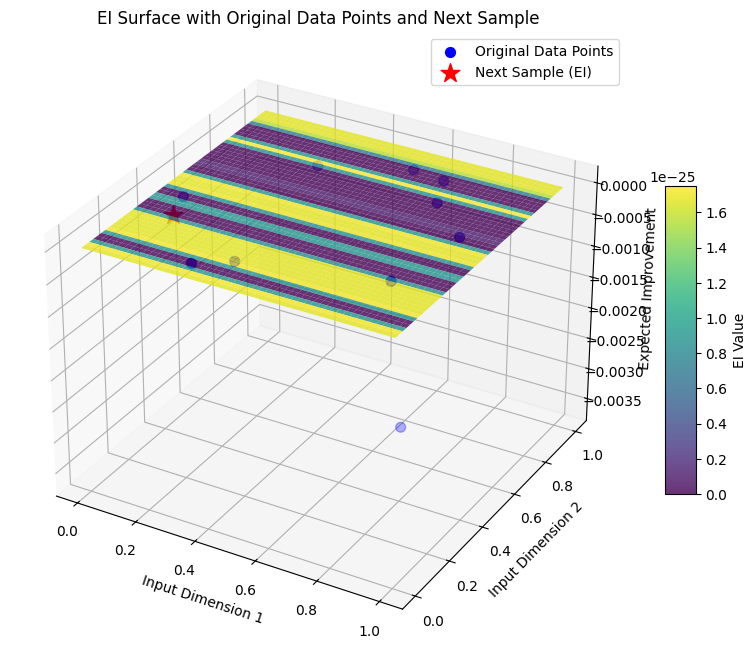

In [36]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Example dataset: two input dimensions (X) and one output variable (y)
# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]x[0,1])
grid_size = 50
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b] for a in x1 for b in x2])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Expected Improvement (EI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

# Select the next input sample as the point with the highest EI
next_index = np.argmax(ei)
next_sample = X_grid[next_index]

# Reshape EI for plotting
EI_surface = ei.reshape(grid_size, grid_size)

# Create a 3D plot for EI surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X1_mesh, X2_mesh = np.meshgrid(x1, x2)

# Plot the EI surface
surf = ax.plot_surface(X1_mesh, X2_mesh, EI_surface, cmap='viridis', alpha=0.8)

# Add original data points (blue circles)
ax.scatter(X[:, 0], X[:, 1], y, color='blue', marker='o', s=50, label='Original Data Points')

# Highlight the selected next point (red star)
ax.scatter(next_sample[0], next_sample[1], mean[next_index], color='red', marker='*', s=200, label='Next Sample (EI)')

# Add labels and title
ax.set_xlabel('Input Dimension 1')
ax.set_ylabel('Input Dimension 2')
ax.set_zlabel('Expected Improvement')
ax.set_title('EI Surface with Original Data Points and Next Sample')

# Add legend and colour bar
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='EI Value')



# Week 1 Submission
0.448979-0.142857

---
---
## Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Use Upper Confidence Bound to encourage exploration

Suggested new points: [[0.7089643625626157, 0.4942696397738492]]


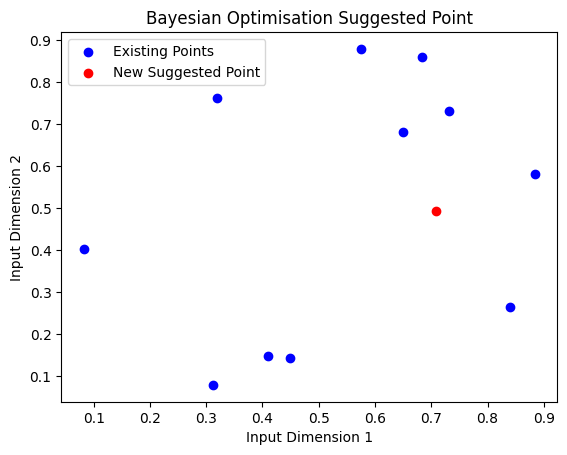

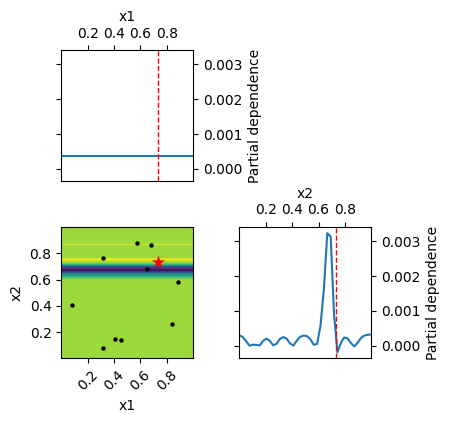

In [21]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.448979, 0.142857])
y.append(2.314080e-56)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose 3 new points
print("Suggested new points:", next_points)

# plot the scatter plot of existing points and the new suggested point
import matplotlib.pyplot as plt
existing_points = np.array(X)
new_point = np.array(next_points[0])
plt.scatter(existing_points[:, 0], existing_points[:, 1], c='blue', label='Existing Points')
plt.scatter(new_point[0], new_point[1], c='red', label='New Suggested Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Bayesian Optimisation Suggested Point')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.708964-0.494269

---
---
## Week 3
No results received from previous late submission - as such, no further insight into improving strategy.
As such, let's adopt LCB acquisition function and set a high kappa to encourage exploration


Suggested new point: 0.986481-0.986619


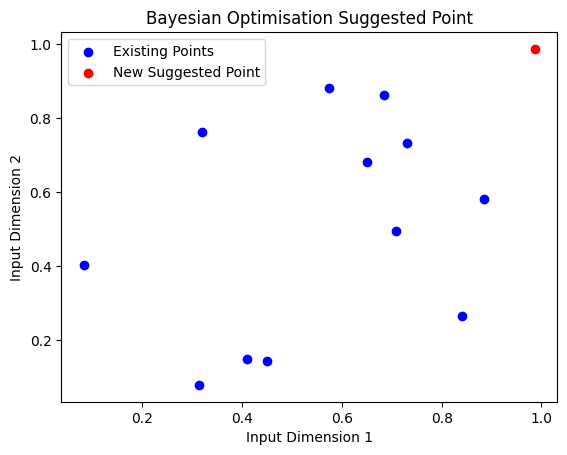

00. X: 0.319404, 0.762959, y:        0.000000
01. X: 0.574329, 0.879898, y:        0.000000
02. X: 0.731024, 0.733000, y:        0.000000
03. X: 0.840353, 0.264732, y:        0.000000
04. X: 0.650114, 0.681526, y:       -0.003606
05. X: 0.410437, 0.147554, y:       -0.000000
06. X: 0.312691, 0.078723, y:       -0.000000
07. X: 0.683418, 0.861057, y:        0.000000
08. X: 0.082507, 0.403488, y:        0.000000
09. X: 0.883890, 0.582254, y:        0.000000
10. X: 0.448979, 0.142857, y:        0.000000
11. X: 0.708964, 0.494269, y:       -0.000000


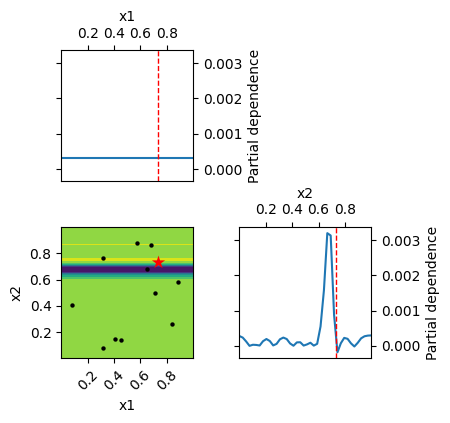

In [5]:
from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="LCB", random_state=42, acq_func_kwargs={'kappa': 10.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.448979, 0.142857])
y.append(2.314080e-56)

# Insert Secong observation
X.append([0.708964, 0.494269])
y.append(-1.159883e-17)


# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}")

# plot the scatter plot of existing points and the new suggested point
import matplotlib.pyplot as plt
existing_points = np.array(X)
new_point = np.array(next_point[0])
plt.scatter(existing_points[:, 0], existing_points[:, 1], c='blue', label='Existing Points')
plt.scatter(new_point[0], new_point[1], c='red', label='New Suggested Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Bayesian Optimisation Suggested Point')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")



---
---
## Week 4
Work and personal challenges over Christmas New Year have caused me a signficant distraction.  Tried to catch up with how to use Neural Nets here, but I really am struggling to understand the application

Previous Sample = 0.986481-0.986619
Previous sample result = 4.977703298633047e-180

### Hyperparameter selection
Observation is that we are not converging at all, widen search area - string exploration

- remain with GP - only starting to get an understanding
- Acquisition Function = LCB
- kappa = 3.5


Suggested new point: 0.060194-0.333985


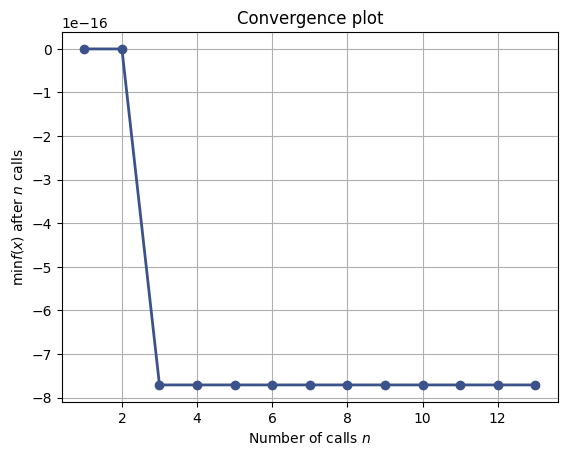

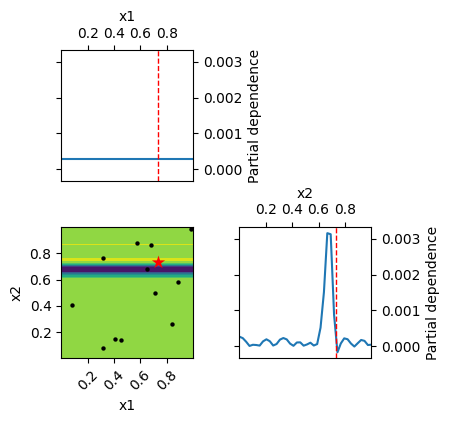

In [49]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "LCB"
random_state = 42
acq_func_kwargs = {'kappa': 3.5}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f1/updated_inputs.npy").tolist()
y = np.load("../data/f1/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)





---
---
## Week 5

### Hyperparameter selection - Last Week Strategy
Observation is that we are not converging at all, widen search area - string exploration

- remain with GP - only starting to get an understanding
- Acquisition Function = LCB
- kappa = 3.5

### Observations - No improvement at all!!

### New Strategy
- change surrogate function to use Gradient Boost instead of GP - on advise of Matilde

Training data shape: X=torch.Size([14, 2]), y=torch.Size([14, 1])
y range: [-3.606063e-03, 7.710875e-16]
Best observed value: 7.710875e-16

Optimized GP hyperparameters:
  Lengthscale: [[0.03672565 0.05632606]]
  Outputscale: 9.400418e-01
  Noise: 1.000000e-04

Next suggested point: [0.742252, 0.742318]
Expected Improvement: -5.607393e+00


/Users/brucediesel/.pyenv/versions/pyDev/lib/python3.13/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


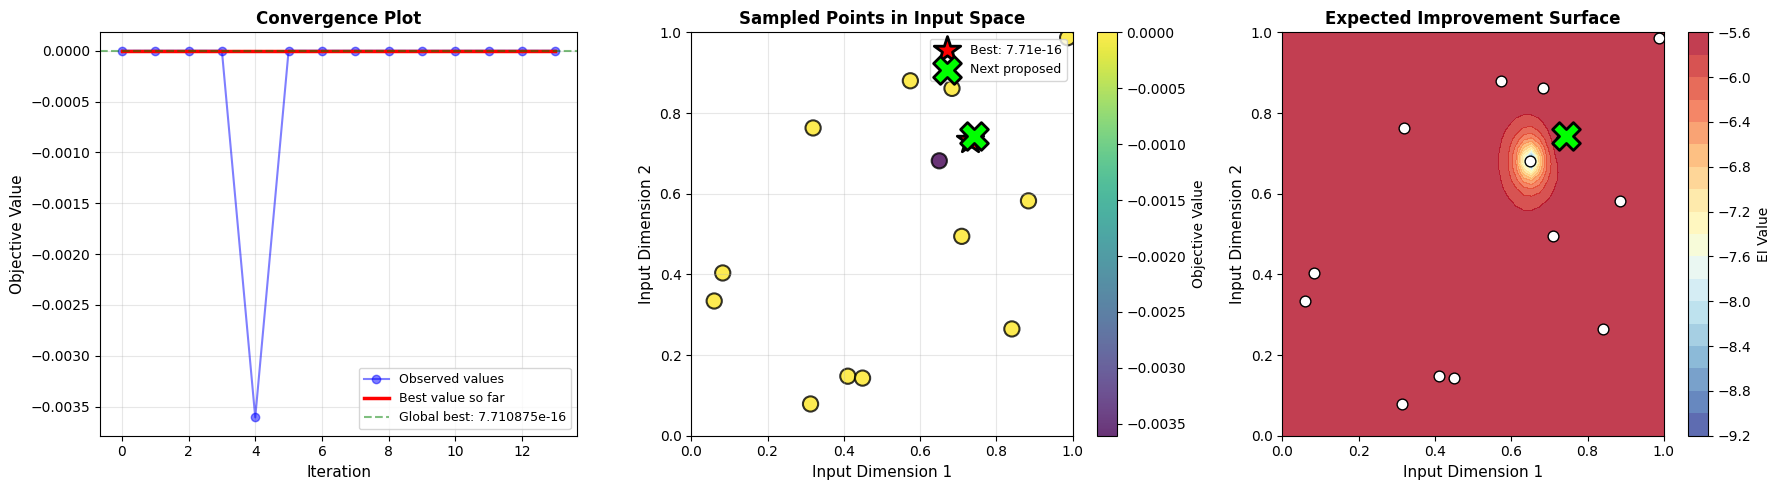


SUMMARY STATISTICS
Total evaluations: 14
Best value found: 7.710875e-16
Best location: [0.731024, 0.733000]
Mean objective: -2.575759e-04
Std objective: 9.287031e-04


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from botorch.models.transforms import Standardize

# Load existing data from numpy files
X_np = np.load("../data/f1/updated_inputs - Week 4.npy")  # Shape: (n_samples, 2)
y_np = np.load("../data/f1/updated_outputs - Week 4.npy")  # Shape: (n_samples,)

# Convert to PyTorch tensors (BoTorch requires double precision)
X_train = torch.tensor(X_np, dtype=torch.float64)
y_train = torch.tensor(y_np, dtype=torch.float64).unsqueeze(-1)  # Shape: (n_samples, 1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"y range: [{y_train.min():.6e}, {y_train.max():.6e}]")
print(f"Best observed value: {y_train.max().item():.6e}")

# Define bounds for the 2D input space [0, 1] x [0, 1]
bounds = torch.tensor([[0.0, 0.0], [1.0, 1.0]], dtype=torch.float64)

# Explicitly set GP hyperparameters
# Matern kernel with nu=2.5 provides good balance between smoothness and flexibility
covar_module = ScaleKernel(
    MaternKernel(
        nu=2.5,  # Smoothness parameter: 2.5 = twice differentiable, good for most functions
        ard_num_dims=2,  # Automatic Relevance Determination: separate lengthscale per input dimension
    )
)

# Set initial lengthscale explicitly (controls correlation decay with distance)
# Smaller values = function varies quickly, larger values = smoother variation
covar_module.base_kernel.lengthscale = torch.tensor([[0.2, 0.2]], dtype=torch.float64)

# Set output scale (controls overall variance of the GP)
covar_module.outputscale = torch.tensor(1.0, dtype=torch.float64)

# Likelihood with explicit noise parameter (observation noise)
# Small noise for near-deterministic functions, larger for noisy observations
likelihood = GaussianLikelihood()
likelihood.noise = torch.tensor(1e-4, dtype=torch.float64)

# Create the GP model with outcome standardization (critical for numerical stability)
# Standardize transforms outputs to zero mean and unit variance
gp_model = SingleTaskGP(
    train_X=X_train,
    train_Y=y_train,
    covar_module=covar_module,
    likelihood=likelihood,
    outcome_transform=Standardize(m=1)  # m=1 for single output dimension
)

# Fit the GP model (optimize hyperparameters via maximum marginal likelihood)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)

print(f"\nOptimized GP hyperparameters:")
print(f"  Lengthscale: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
print(f"  Outputscale: {gp_model.covar_module.outputscale.detach().item():.6e}")
print(f"  Noise: {gp_model.likelihood.noise.detach().item():.6e}")

# Define Expected Improvement (EI) acquisition function
# EI balances exploitation (high mean) and exploration (high uncertainty)
# Best for maximization: finds points likely to exceed current best
best_f = y_train.min()  # Best observed value (for maximization)
ei = LogExpectedImprovement(model=gp_model, best_f=best_f)

# Optimize the acquisition function to find next sampling point
# More restarts and raw_samples = more thorough search but slower
candidate, acq_value = optimize_acqf(
    acq_function=ei,
    bounds=bounds,
    q=1,  # Number of points to propose (1 = sequential optimization)
    num_restarts=20,  # Random restarts for optimization (reduces local optima risk)
    raw_samples=512,  # Initial random candidates to evaluate before optimization
)

next_x = candidate.detach().numpy()[0]
print(f"\n{'='*60}")
print(f"Next suggested point: [{next_x[0]:.6f}, {next_x[1]:.6f}]")
print(f"Expected Improvement: {acq_value.item():.6e}")
print(f"{'='*60}")

# Comprehensive visualization
fig = plt.figure(figsize=(18, 5))

# Plot 1: Convergence - Best value found over iterations
ax1 = plt.subplot(1, 3, 1)
iterations = np.arange(len(y_np))
cumulative_best = np.maximum.accumulate(y_np)  # Running maximum

ax1.plot(iterations, y_np, 'b-o', alpha=0.5, markersize=6, label='Observed values')
ax1.plot(iterations, cumulative_best, 'r-', linewidth=2.5, label='Best value so far')
ax1.axhline(y=y_np.max(), color='g', linestyle='--', alpha=0.5, label=f'Global best: {y_np.max():.6e}')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Objective Value', fontsize=11)
ax1.set_title('Convergence Plot', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: 2D scatter of sampled points in input space
ax2 = plt.subplot(1, 3, 2)
scatter = ax2.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='viridis', s=120, 
                      edgecolors='black', linewidth=1.5, alpha=0.8)
best_idx = np.argmax(y_np)
ax2.scatter(X_np[best_idx, 0], X_np[best_idx, 1], c='red', s=400, marker='*', 
            edgecolors='black', linewidths=2, label=f'Best: {y_np[best_idx]:.2e}', zorder=5)
ax2.scatter(next_x[0], next_x[1], c='lime', s=400, marker='X', 
            edgecolors='black', linewidths=2, label='Next proposed', zorder=5)
ax2.set_xlabel('Input Dimension 1', fontsize=11)
ax2.set_ylabel('Input Dimension 2', fontsize=11)
ax2.set_title('Sampled Points in Input Space', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Objective Value', fontsize=10)

# Plot 3: Expected Improvement surface
ax3 = plt.subplot(1, 3, 3)
grid_size = 50
x1_grid = np.linspace(0, 1, grid_size)
x2_grid = np.linspace(0, 1, grid_size)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_test = torch.tensor(np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()]), dtype=torch.float64)

# Evaluate EI on grid
with torch.no_grad():
    ei_values = ei(X_test.unsqueeze(1)).numpy()

ei_surface = ei_values.reshape(grid_size, grid_size)
contour = ax3.contourf(X1_mesh, X2_mesh, ei_surface, levels=20, cmap='RdYlBu_r', alpha=0.8)
ax3.scatter(X_np[:, 0], X_np[:, 1], c='white', s=60, edgecolors='black', linewidth=1, zorder=3)
ax3.scatter(next_x[0], next_x[1], c='lime', s=400, marker='X', 
            edgecolors='black', linewidths=2, zorder=5)
ax3.set_xlabel('Input Dimension 1', fontsize=11)
ax3.set_ylabel('Input Dimension 2', fontsize=11)
ax3.set_title('Expected Improvement Surface', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])
cbar2 = plt.colorbar(contour, ax=ax3)
cbar2.set_label('EI Value', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print(f"SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total evaluations: {len(y_np)}")
print(f"Best value found: {y_np.max():.6e}")
print(f"Best location: [{X_np[best_idx, 0]:.6f}, {X_np[best_idx, 1]:.6f}]")
print(f"Mean objective: {y_np.mean():.6e}")
print(f"Std objective: {y_np.std():.6e}")
print(f"{'='*60}")

In [ ]:
import torch
import numpy as np

from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.sampling import draw_sobol_samples


def propose_next_point_ei(
    X_train, y_train,
    bounds_np,                 # shape (2, d): [lower; upper]
    maximize=False,            # set True if maximizing
    ensemble_size=25,
    gbrt_params=None,
    mc_samples=256,
    n_candidates=4096,
    seed=0,
    device=None,
):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.double)

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train).reshape(-1)

    # EI assumes maximization; flip sign for minimization problems
    y_model = y_train if maximize else -y_train

    # Fit ensemble
    estimators = SklearnGBRTEnsembleModel.fit_bootstrap_ensemble(
        X_train=X_train,
        y_train=y_model,
        ensemble_size=ensemble_size,
        bootstrap_ratio=1.0,
        gbrt_params=gbrt_params,
        seed=seed,
    )

    model = SklearnGBRTEnsembleModel(estimators, device=device, dtype=torch.double).to(device)

    # best_f is best observed objective value (in maximization space)
    best_f = torch.tensor(y_model.max(), device=device, dtype=torch.double)

    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([mc_samples]))
    acqf = qExpectedImprovement(model=model, best_f=best_f, sampler=sampler)

    bounds = torch.tensor(bounds_np, device=device, dtype=torch.double)  # (2, d)

    # Candidate set (q=1 for a single next point)
    X_cand = draw_sobol_samples(bounds=bounds, n=n_candidates, q=1).to(device)

    with torch.no_grad():
        vals = acqf(X_cand)  # (n_candidates,)

    best_idx = torch.argmax(vals).item()
    x_next = X_cand[best_idx, 0, :].detach().cpu().numpy()
    return x_next